In [1]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import torch
from flonacomldft.utils.io_utils import (
    load_from_pickle, load_zmat_csv, load_csv_file, get_path, 
)
from flonacomldft.utils.data_processing import get_mix_data
# from flonacomldft.models import Uncentered_MLP
from flonacomldft.models.mixture import Mixture, get_models
# from flonacomldft.dft_utils import Coordinates_mapping
# from flonacomldft.internal_coordinates import Angles_mapping

In [2]:
data_path = get_path()
data_path

'/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/'

In [3]:
import os
os.listdir(data_path)

['x_nf_is2.csv',
 'x_nf_is1.csv',
 'is2_xyz.csv',
 'is1_lcao_zmat_rf.csv',
 'is1_zmat.csv',
 'ag6_is2_lcao.traj',
 'is1_xyz.csv',
 'mlp_is2',
 'training_is1',
 'is2_zmat.csv',
 'is1_lcao_zmat.csv',
 'is2_lcao_zmat_rf.csv',
 'mlp_is1',
 'unrotated_300.txt',
 'is2_lcao_zmat.csv',
 'training_is2',
 'ag6_is1_lcao.traj']

In [4]:
data_is1 = load_zmat_csv("is1")
data_is2 = load_zmat_csv("is2")

xis, uis, cis = get_mix_data(data_is1, data_is2)

# Pretrain mlps and flows

# loading pretrain mlps models
mlp_is1 = load_from_pickle(get_path() + "mlp_is1")
mlp_is2 = load_from_pickle(get_path() + "mlp_is2")

# loading pretrain flows models
nf_is1 = load_from_pickle(get_path() + "training_is1")
nf_is2 = load_from_pickle(get_path() + "training_is2")

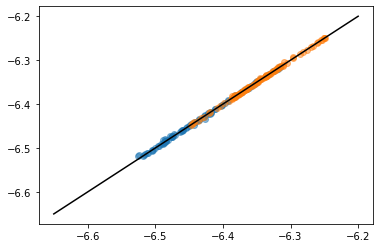

In [6]:
## Looking at the data: 
n_test = 100
slip = 500
plt.scatter(mlp_is1.predict((data_is1[slip:slip+n_test,:-1])).detach(), data_is1[slip:slip+n_test,-1].detach(), alpha=0.5)
plt.scatter(mlp_is2.predict((data_is2[slip:slip+n_test,:-1])).detach(), data_is2[slip:slip+n_test,-1].detach(), alpha=0.5)
plt.plot([-6.65, -6.2],[-6.65, -6.2], 'k-')

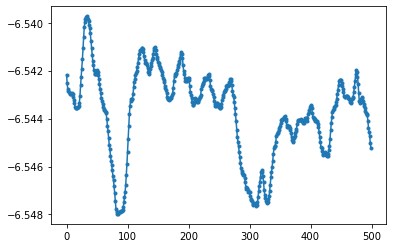

In [7]:
slip=4500
n_test=500
plt.plot(data_is2[slip:slip+n_test,-1], '.-')

In [ ]:
flow_train = [
    [nf_is1, nf_is2],
]
flow = [
    get_models(flow_train[0]),
]
mlps = [[mlp_is1, mlp_is2]]

weights = torch.tensor([0.5, 0.5]).detach()
mixture = Mixture(flow[0], weights)

n_runs = 1
n_chains = 5
n_sts = 3
energy_type = "mlp-dft" #"dft"  

# init sampling
_ = run_metropolis(
    model=mixture,
    u_init=uis[:n_chains],
    x_init=xis[:n_chains, :],
    count_init=cis[:n_chains],
    n_chains=n_chains,
    n_steps=n_sts,
    energy_type=energy_type,
    mlps=mlps[0],
    mixture=True,
)

In [ ]:
# T=300
# kb = 8.617333262e-5
# beta = 1/(kb*T)

# def run_metropolis_MLP(model, u_init, x_init, count_init, mlps, n_sample, n_steps, mixture=False):

#     xs = []
#     accs = []
#     us = []
#     us_p = []
#     nlls = []
#     counts = []
    
#     u_init=u_init[:n_sample]
#     x_init=x_init[:n_sample]
#     count_init=count_init[:n_sample]

#     mlp_is1, mlp_is2 = mlps

#     M = Angles_mapping()

#     for dt in range(n_steps):

#         M.inv_mapping(x_init)
        
#         if mixture:
#             x, count = model.sample(n_sample, return_mus=True)
#         else:
#             x = model.sample(n_sample)
#             count = count_init
                        
#         x = torch.tensor(x).detach().float()
#         count = torch.tensor(count).detach().float()
    
#         nll_x = model.nll(x)
#         nll_x_init = model.nll(x_init)
    
#         M.mapping(x)
#         M.mapping(x_init)

#         U_ = torch.zeros((x.shape[0], 1))

#         if(count.sum().int()==count.shape[0]):
#             U_[count.bool()] = mlp_is2(x[count.bool()])
#         if(count.sum().int()==0):
#             U_[~(count.bool())] = mlp_is1(x[~(count.bool())])
#         else:
#             U_[~(count.bool())] = mlp_is1(x[~(count.bool())])
#             U_[count.bool()] = mlp_is2(x[count.bool()])
        
#         U = U_.clone()
#         U = U.reshape(U_.shape[0])

#         ratio =  - beta * (U) + nll_x
#         ratio += beta * u_init - nll_x_init
#         ratio = torch.exp(ratio)
#         u = torch.rand_like(ratio)
#         acc = u < torch.min(ratio, torch.ones_like(ratio))

#         x[~acc] = x_init[~acc]
#         U[~acc] = u_init[~acc]
        
#         if mixture:
#             count[~acc] = count_init[~acc]
#         else:
#             count = count_init

#         xs.append(x.float().clone())
#         accs.append(acc.float().clone())
#         us.append(U.float().clone())
#         us_p.append(U_.float().clone())
#         nlls.append(nll_x.float().clone())
#         counts.append(count.float().clone())

#         x_init = x.clone()
#         u_init = U.clone()
#         count_init = count.clone()
            
#         print("Acceptance porcentage: %.1f%%"%(np.array(acc).sum()*100/len(acc)))

#     to_return = {
#         'xs': torch.stack(xs),
#         'accs': torch.stack(accs),
#         'us': torch.stack(us),
#         'us_p': torch.stack(us_p),
#         'counts': torch.stack(counts)
#     }

#     return to_return